In [1]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [2]:
! pwd

/Users/alyulina/Projects/Cancer/Code


In [3]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TGCT', 'TGTG', 'TTCC', 'TTGG']

# cell lines; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_ine', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'Spike-in2', 'Spike-in3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the first run
samples = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 45)]

In [4]:
sample_clID_counts = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples):
    
    sample_clID_counts.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts[i][j] = [] # initiating lists for counts for each cell line within a sample
        
    for line in open('../Data/bc_counts/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
        

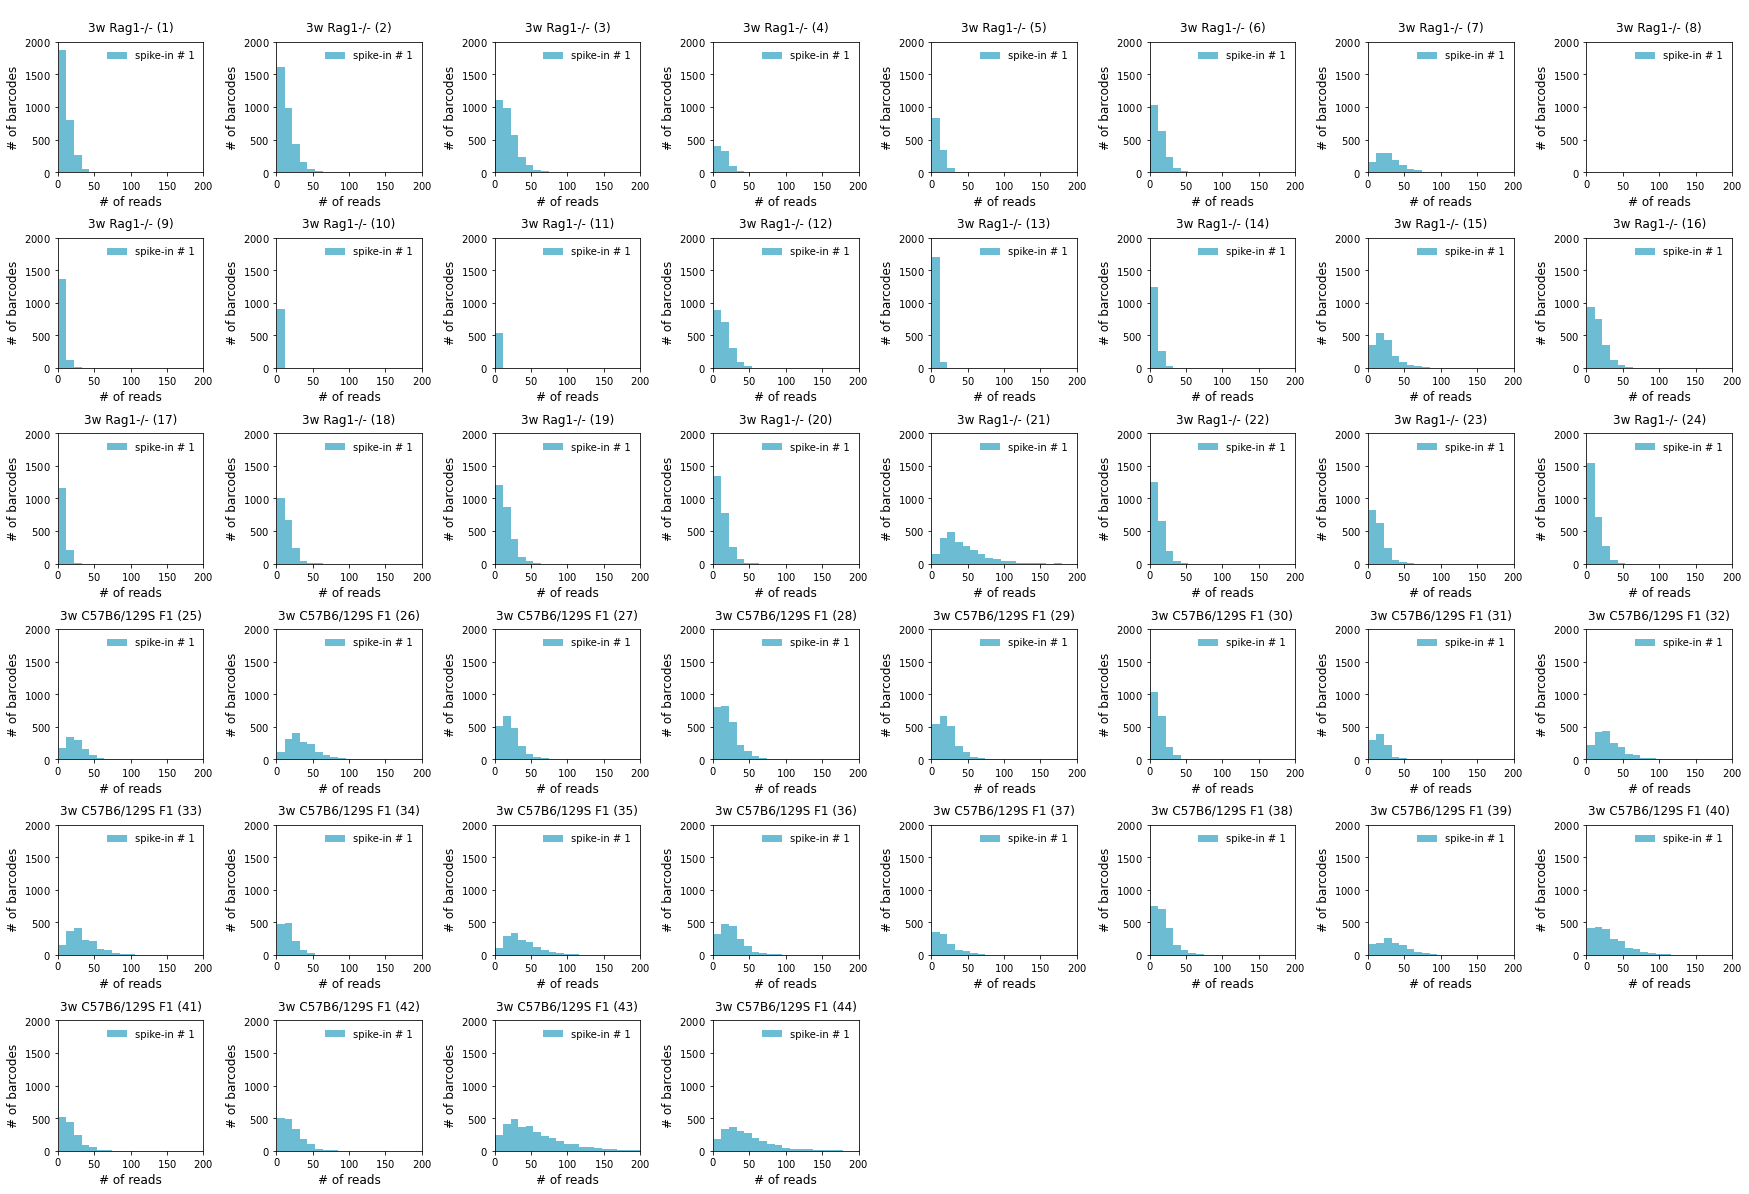

In [6]:
# spike-in 1 read count distributions across samples, on log scale

plt.figure(figsize=(30, 24))

grid = gridspec.GridSpec(ncols=8, nrows=7,
                         width_ratios=[1, 1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1, 1], hspace=0.5)

c = 0
for i in range(len(samples)):
    
    plt.subplot(grid[c // 8, c % 8])
    
    plt.hist([x[-1] for x in sample_clID_counts[i][cell_line_dict['Spike-in1']]], 
             bins=np.linspace(1, 200, 20), color='#6cbdd4', label='spike-in # 1')

    
    plt.ylim(0, 2000)
    plt.xlim(0, 200)
    plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([0, 50, 100, 150, 200], ['0', '$50$', '$100$', '$150$', '$200$'], fontsize=10)

   
    plt.xlabel('# of reads', fontsize=12)
    plt.ylabel('# of barcodes', fontsize=12)

    
    if i < 24:
        title = '\n' + '3w Rag1-/- (' + str(i + 1) + ')'
    else:
        title = '3w C57B6/129S F1 (' + str(i + 1) + ')'
    
    plt.title(title, fontsize=12, pad=10)
    
    plt.legend(frameon=False)
    
    c += 1
    
plt.savefig('spike-in1_bc_distr.png', dpi=300, bbox_inches='tight')

In [ ]:
# looking at correlations between replicates on log-log scale: counts;

plt.figure(figsize=(30, 24))

grid = gridspec.GridSpec(ncols=8, nrows=7,
                         width_ratios=[1, 1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1, 1], hspace=0.5)

c = 0
for i in range(len(samples)):
    
    plt.subplot(grid[c // 8, c % 8])
    
    plt.hist([x[-1] for x in sample_clID_counts[i][cell_line_dict['mT4-2D']]],
             color='#6cbdd4', label='mT4-2D', bins=20)
    
    xmin, xmax = plt.xlim()
    #if xmax > 50000:
    #    plt.axvline(50000, color='black')

    
    # plt.ylim(0, 0.0003)
    # plt.xlim(0, 400000)
    #plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    #plt.xticks([0, 50, 100, 150, 200], ['0', '$50$', '$100$', '$150$', '$200$'], fontsize=10)

   
    plt.xlabel('# of reads', fontsize=12)
    plt.ylabel('# of barcodes', fontsize=12)

    
    if i < 24:
        title = '\n' + '3w Rag1-/- (' + str(i + 1) + ')'
    else:
        title = '3w C57B6/129S F1 (' + str(i + 1) + ')'
    
    plt.title(title, fontsize=12, pad=10)
    
    plt.legend(frameon=False)
    
    c += 1
    
plt.savefig('mT4-2D_bc_distr.png', dpi=300, bbox_inches='tight')

In [7]:
mT42D_distr = []
mT42D_distr_top10 = []
for i in range(len(samples)):
    tuples = sorted(sample_clID_counts[i][cell_line_dict['mT4-2D']], reverse=True, key=lambda y: y[-1])
    mT42D_distr.append(dict(zip([x[0] for x in tuples], [x[1] for x in tuples])))
    mT42D_distr_top10.append(dict(zip([x[0] for x in tuples[:10]], [x[1] for x in tuples[:10]])))

In [8]:
overlapping_bc_mT42D_top_10 = []
for i, j in combinations(list(range(len(samples))), 2):
    overlapping_bc_mT42D_top_10.append(list(set(mT42D_distr_top10[i].keys()).intersection(set(mT42D_distr_top10[j].keys()))))
    

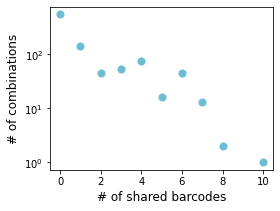

In [12]:
plt.figure(figsize=(4, 3))

plt.scatter([z[0] for z in [[x, [len(y) for y in overlapping_bc_mT42D_top_10].count(x)] for x in set([len(y) for y in overlapping_bc_mT42D_top_10])]],
            [z[1] for z in [[x, [len(y) for y in overlapping_bc_mT42D_top_10].count(x)] for x in set([len(y) for y in overlapping_bc_mT42D_top_10])]],
            color='#6cbdd4', s=50)
#plt.ylim(-100, 700);
plt.yticks([0, 200, 400, 600]);
plt.xlabel('# of shared barcodes', fontsize=12)
plt.ylabel('# of combinations', fontsize=12)
plt.yscale('log')
plt.minorticks_off()

# plt.savefig('mT4-2D_shared_bc.png', dpi=300, bbox_inches='tight')

In [13]:
overlapping_bc_mT42D = []
overlapping_bc_mT42D_outliers = []
overlapping_bc_mT42D_all = []
for i, j in combinations(list(range(len(samples))), 2):
    overlapping_bc = list(set([x[0] for x in sample_clID_counts[i][cell_line_dict['mT4-2D']]]).intersection(set([x[0] for x in sample_clID_counts[j][cell_line_dict['mT4-2D']]])))
    overlapping_bc_outliers = list(set([x[0] for x in sample_clID_counts[i][cell_line_dict['mT4-2D']] if x[1] >= 10000]).intersection(set([x[0] for x in sample_clID_counts[j][cell_line_dict['mT4-2D']] if x[1] >= 10000])))
    
    overlapping_bc_counts = [[mT42D_distr[i][x] for x in overlapping_bc], [mT42D_distr[j][x] for x in overlapping_bc]]
    overlapping_bc_outliers_counts = [[mT42D_distr[i][x] for x in overlapping_bc_outliers], [mT42D_distr[j][x] for x in overlapping_bc_outliers]]
    
    overlapping_bc_mT42D.append([overlapping_bc, overlapping_bc_counts])  
    overlapping_bc_mT42D_outliers.append([overlapping_bc_outliers, overlapping_bc_outliers_counts])  
    overlapping_bc_mT42D_all.extend(overlapping_bc)      
          
overlapping_bc_mT42D_all = list(set(overlapping_bc_mT42D_all))          

In [14]:
overlapping_bc_mT42D_pooled_counts = [item for sublist in [x[-1][0] + x[-1][1] for x in overlapping_bc_mT42D] for item in sublist] 

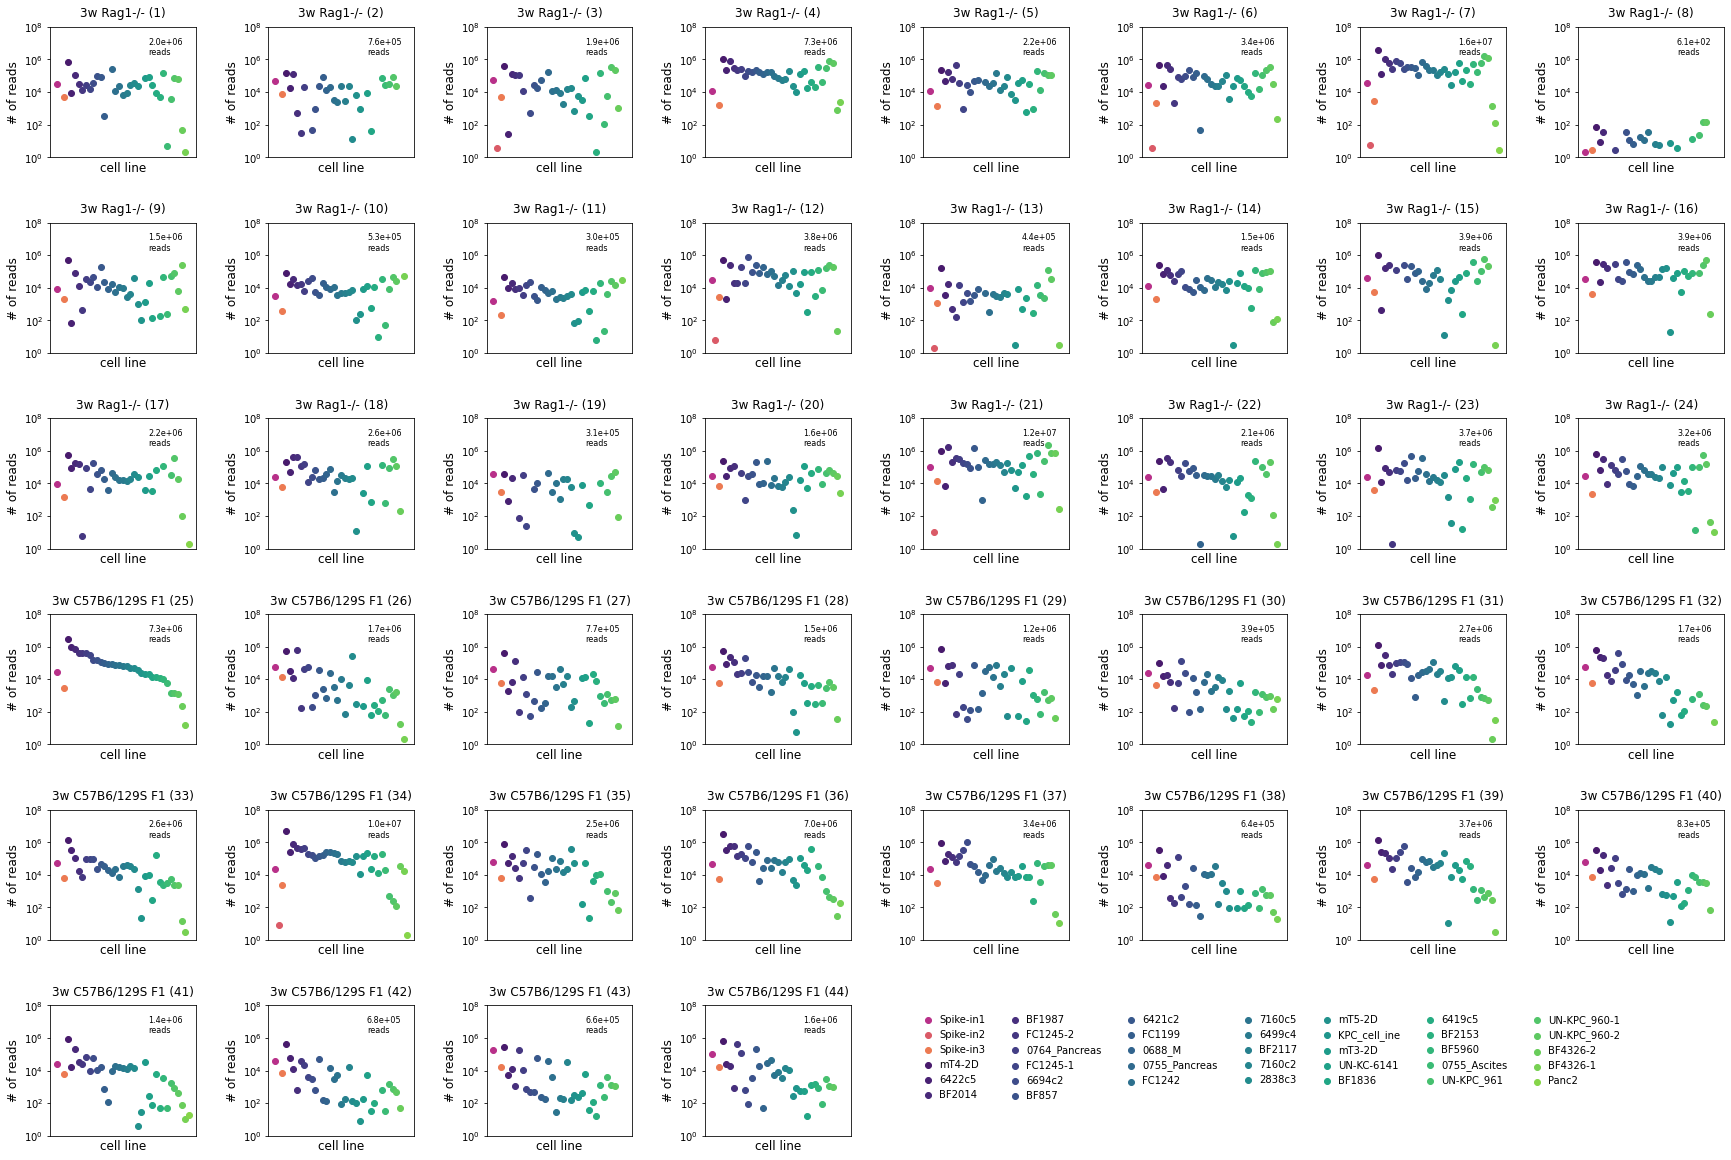

In [15]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(samples)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(30, 24))

grid = gridspec.GridSpec(ncols=8, nrows=7,
                         width_ratios=[1, 1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1, 1], hspace=0.5)

c = 0
for i in range(len(samples)):
    
    plt.subplot(grid[c // 8, c % 8])
    
    
    # based on sample 24
    order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
    
    n_cells_total = 0
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
            n_cells_total += n_bc_total
            plt.scatter(count, n_bc_total, label=cell_lines[j], color=viridis.to_rgba(count))
        
        elif cell_lines[j][:5] == 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
            plt.scatter(count, n_bc_total, label=cell_lines[j], color=colors[count])
       

    plt.yscale('log'); plt.minorticks_off()
    plt.ylim(1, 1e8)
    # plt.xlim(0, 200)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([], [])

   
    plt.xlabel('cell line', fontsize=12)
    plt.ylabel('# of reads', fontsize=12)
    
    plt.text(25, 2e6, '{:.1e}'.format(n_cells_total) + '\nreads', fontsize=8, color='black')

    
    if i < 24:
        title = '3w Rag1-/- (' + str(i + 1) + ')'
    else:
        title = '3w C57B6/129S F1 (' + str(i + 1) + ')'
    
    plt.title(title, fontsize=12, pad=10)
    
    if i == len(samples) - 1:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1.4, 1))
    
    c += 1
    
# plt.savefig('total_n_reads_per_cell_line.png', dpi=300, bbox_inches='tight')

In [ ]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(samples)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(30, 24))

grid = gridspec.GridSpec(ncols=8, nrows=7,
                         width_ratios=[1, 1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1, 1], hspace=0.5)

c = 0
for i in range(len(samples)):
    
    plt.subplot(grid[c // 8, c % 8])
    
    if i != 24: 
        # based on sample 24
        order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
    
        n_cells_total = 0
        to_sort = []
        for count, j in enumerate(order):
        
            if cell_lines[j][:5] != 'Spike':
                n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
                n_cells_total += n_bc_total
                to_sort.append([n_bc_total, cell_lines[j], count])
        
            elif cell_lines[j][:5] == 'Spike':
                n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
                plt.scatter(count, n_bc_total, color=colors[count])
    
        to_sort_sorted = sorted(to_sort, reverse=True, key = lambda y: [y[0]]) # n bc, label, color  
        plt.scatter(range(3, len(to_sort) + 3), [x[0] for x in to_sort_sorted],
                color=[viridis.to_rgba(x[-1]) for x in to_sort_sorted])
        
        plt.text(4, 2 * to_sort_sorted[0][0], to_sort_sorted[0][1], fontsize=8, color=viridis.to_rgba(to_sort_sorted[0][-1]))
        plt.text(25, 2e6, '{:.1e}'.format(n_cells_total) + '\nreads', fontsize=8, color='black')
    
    else: # this is just to make the legend work
        n_cells_total = 0
        for count, j in enumerate(order):
        
            if cell_lines[j][:5] != 'Spike':
                n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
                n_cells_total += n_bc_total
                plt.scatter(count, n_bc_total, label=cell_lines[j], color=viridis.to_rgba(count))
                if count == 3:
                    plt.text(4, 2 * n_bc_total, cell_lines[j], fontsize=8, color=viridis.to_rgba(count))

        
            elif cell_lines[j][:5] == 'Spike':
                n_bc_total = np.sum([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
                plt.scatter(count, n_bc_total, label=cell_lines[j], color=colors[count])
                
        plt.text(25, 2e6, '{:.1e}'.format(n_cells_total) + '\nreads', fontsize=8, color='black')
        

    plt.yscale('log'); plt.minorticks_off()
    plt.ylim(1, 1e8)
    # plt.xlim(0, 200)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([], [])

   
    plt.xlabel('cell line', fontsize=12)
    plt.ylabel('# of reads', fontsize=12)
    


    
    if i < 24:
        title = '3w Rag1-/- (' + str(i + 1) + ')'
    else:
        title = '3w C57B6/129S F1 (' + str(i + 1) + ')'
    
    plt.title(title, fontsize=12, pad=10)
    
    if i == 24:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(10.8, -2.1))
    
    c += 1
    
# plt.savefig('total_n_reads_per_cell_line_sorted.png', dpi=300, bbox_inches='tight')

In [ ]:
# same as before but now w/ the number of barcodes

viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(samples)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(30, 24))

grid = gridspec.GridSpec(ncols=8, nrows=7,
                         width_ratios=[1, 1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1, 1], hspace=0.5)

c = 0
for i in range(len(samples)):
    
    plt.subplot(grid[c // 8, c % 8])
    
    # based on sample 24
    order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
    
    n_cells_total = 0
    to_sort = []
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = len([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
            n_cells_total += n_bc_total
            to_sort.append([n_bc_total, cell_lines[j], count])
        
        elif cell_lines[j][:5] == 'Spike':
            n_bc_total = len([x[-1] for x in sample_clID_counts[i][clIDs[j]]])
            plt.scatter(count, n_bc_total, color=colors[count])
    
    to_sort_sorted = sorted(to_sort, reverse=True, key = lambda y: [y[0]]) # n bc, label, color  
    plt.scatter(range(3, len(to_sort) + 3), [x[0] for x in to_sort_sorted],
                color=[viridis.to_rgba(x[-1]) for x in to_sort_sorted])
        
    plt.text(4, 2 * to_sort_sorted[0][0], to_sort_sorted[0][1], fontsize=8, color=viridis.to_rgba(to_sort_sorted[0][-1]))        
    #plt.text(25, 2e6, '{:.1e}'.format(n_cells_total) + '\nreads', fontsize=8, color='black')
    
   
    plt.yscale('log'); plt.minorticks_off()
    plt.ylim(0.5, 2e4)
    # plt.xlim(0, 200)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([], [])
    plt.yticks([10, 100, 1000])

   
    plt.xlabel('cell line', fontsize=12)
    plt.ylabel('# of barcodes', fontsize=12)
    


    
    if i < 24:
        title = '3w Rag1-/- (' + str(i + 1) + ')'
    else:
        title = '3w C57B6/129S F1 (' + str(i + 1) + ')'
    
    plt.title(title, fontsize=12, pad=10)
    
    #if i == 24:
    #    plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(10.8, -2.1))
    
    c += 1
    
# plt.savefig('total_n_bc_per_cell_line_sorted.png', dpi=300, bbox_inches='tight')

In [ ]:
n_rag1 = []
n_f1 = []
for i in range(len(clIDs)):
    
    if cell_lines[i][:5] != 'Spike':
    
        n_rag1_i = []
        for j in range(0, 24):
            n_rag1_i.append(sum([x[-1] for x in sample_clID_counts[j][clIDs[i]]]))
    
        n_f1_i = []   
        for j in range(24, 44):
            n_f1_i.append(sum([x[-1] for x in sample_clID_counts[j][clIDs[i]]]))
        
        n_rag1.append([np.mean(n_rag1_i), np.std(n_rag1_i)])
        n_f1.append([np.mean(n_f1_i), np.std(n_f1_i)])
        
        
ind = [n_f1.index(x) for x in sorted(n_f1, reverse=True, key=lambda y: y[0])]

plt.figure(figsize=(8, 6))

plt.scatter(range(len(n_rag1)), [n_rag1[i][0] for i in ind], color='#6cbdd4', label = 'mean across Rag1-/- mice')
plt.vlines(range(len(n_rag1)), [n_rag1[i][0] - n_rag1[i][1] for i in ind], [n_rag1[i][0] + n_rag1[i][1] for i in ind], color='#6cbdd4', label='standard deviation across Rag1-/- mice')

plt.scatter(range(len(n_f1)), [n_f1[i][0] for i in ind], color='#e0e055', label = 'mean across C57B6/129S F1 mice')
plt.vlines(range(len(n_f1)), [n_f1[i][0] - n_f1[i][1] for i in ind], [n_f1[i][0] + n_f1[i][1] for i in ind], color='#e0e055', label='standard deviation across C57B6/129S F1 mice')

plt.xticks(range(len([x for x in cell_lines if 'Spike' not in x])), [[x for x in cell_lines if 'Spike' not in x][i] for i in ind], rotation=90);

plt.xlabel('cell line', fontsize=12)
plt.ylabel('# of reads', fontsize=12)

plt.legend(frameon=False);
# plt.yscale('log')

# plt.savefig('total_n_reads_per_cell_line_merged.png', dpi=300, bbox_inches='tight')

In [ ]:
n_rag1 = []
n_f1 = []
for i in range(len(clIDs)):
    
    if cell_lines[i][:5] != 'Spike':
    
        n_rag1_i = []
        for j in range(0, 24):
            n_rag1_i.append(len([x[-1] for x in sample_clID_counts[j][clIDs[i]]]))
    
        n_f1_i = []   
        for j in range(24, 44):
            n_f1_i.append(len([x[-1] for x in sample_clID_counts[j][clIDs[i]]]))
        
        n_rag1.append([np.mean(n_rag1_i), np.std(n_rag1_i)])
        n_f1.append([np.mean(n_f1_i), np.std(n_f1_i)])
        
ind = [n_f1.index(x) for x in sorted(n_f1, reverse=True, key=lambda y: y[0])]

plt.figure(figsize=(8, 6))

plt.scatter(range(len(n_rag1)), [n_rag1[i][0] for i in ind], color='#6cbdd4', label = 'mean across Rag1-/- mice')
plt.vlines(range(len(n_rag1)), [n_rag1[i][0] - n_rag1[i][1] for i in ind], [n_rag1[i][0] + n_rag1[i][1] for i in ind], color='#6cbdd4', label='standard deviation across Rag1-/- mice')

plt.scatter(range(len(n_f1)), [n_f1[i][0] for i in ind], color='#e0e055', label = 'mean across C57B6/129S F1 mice')
plt.vlines(range(len(n_f1)), [n_f1[i][0] - n_f1[i][1] for i in ind], [n_f1[i][0] + n_f1[i][1] for i in ind], color='#e0e055', label='standard deviation across C57B6/129S F1 mice')

plt.xticks(range(len([x for x in cell_lines if 'Spike' not in x])), [[x for x in cell_lines if 'Spike' not in x][i] for i in ind], rotation=90);
plt.yticks([0, 100, 200, 300, 400])

plt.ylim(-50, 450)

plt.xlabel('cell line', fontsize=12)
plt.ylabel('# of barcodes', fontsize=12)

plt.legend(frameon=False);
# plt.yscale('log')

# plt.savefig('total_n_bc_per_cell_line_merged.png', dpi=300, bbox_inches='tight')

In [ ]:
all_lines_rag1_id = []
all_lines_f1_id = []
for count, j in enumerate(cell_lines):
    if j[:5] != 'Spike':
        all_lines_rag1_id.append([all_lines_rag1[count], j])
        all_lines_f1_id.append([all_lines_f1[count], j])

all_lines_rag1_id_sorted = sorted(all_lines_rag1_id, key=lambda x: x[0], reverse=True)
all_lines_f1_id_sorted = sorted(all_lines_f1_id, key=lambda x: x[0], reverse=True)

In [ ]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=-10, vmax=35), 
                                       cmap=plt.get_cmap('viridis'))

for i in range(len(all_lines_f1_id_sorted)):
    plt.scatter(i, all_lines_f1_id_sorted[i][0], label=all_lines_f1_id_sorted[i][-1],
                color=viridis.to_rgba(i))
    
plt.xticks([], [])
plt.yticks([0, 0.5e7, 1e7, 1.5e7])

plt.xlabel('cell line', fontsize=12)
plt.ylabel('# of reads', fontsize=12)
    
plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(2, -0.5))
        

In [ ]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=24), 
                                       cmap=plt.get_cmap('viridis'))

for i in range(len(all_lines_rag1_id_sorted)):
    plt.scatter(i, all_lines_rag1_id_sorted[i][0],
                color=viridis.to_rgba([x[-1] for x in all_lines_f1_id_sorted].index(all_lines_rag1_id_sorted[i][-1])))
    
plt.xticks([], [])
plt.yticks([0, 0.5e7, 1e7, 1.5e7])

plt.xlabel('cell line', fontsize=12)
plt.ylabel('# of reads', fontsize=12)
    


In [ ]:
plt.scatter(range(len(all_lines_rag1_id_sorted)), [x[0] for x in all_lines_rag1_id_sorted], label=[x[-1] for x in all_lines_rag1_id_sorted])
#plt.legend(frameon=False)


In [ ]:
plt.scatter(range(len(all_lines_rag1_id_sorted)), [x[0] for x in all_lines_rag1_id_sorted], label=[x[-1] for x in all_lines_rag1_id_sorted])
#plt.legend(frameon=False)



In [ ]:
# metastatic burden per sample
n_cells_per_sample = {}
for i, sample in enumerate(samples):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike':
            counts += sum([x[-1] for x in sample_clID_counts[i][j]])
            
    n_cells_per_sample[sample] = counts     

In [ ]:
# metastatic burden per sample
n_reads_spiked = 0
for i, sample in enumerate(samples):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j) in ['Spike-in1', 'Spike-in3']:
            counts += sum([x[-1] for x in sample_clID_counts[i][j]])
            
    n_reads_spiked += counts     

In [ ]:
data = [[n_cells_per_sample.get(i) for i in samples if int(i.split('_')[-1]) < 25],
        [n_cells_per_sample.get(i) for i in samples if int(i.split('_')[-1]) > 24]]

violins = plt.violinplot(data, vert=True, showmedians=False, showextrema=False)
plt.scatter([1 for x in data[0]], data[0], color='#6cbdd4')
plt.scatter([2 for x in data[1]], data[1], color='#6cbdd4')

means = [np.mean(x) for x in data]
sems = [sp.stats.sem(x) for x in data]
stds = [np.std(x) for x in data]
plt.scatter([1, 2], means, marker='o', color='black', s=30, zorder=3, label='mean')
plt.vlines([1, 2], [x - y for x, y in zip(means, stds)], [x + y for x, y in zip(means, stds)], color='black', lw=2, zorder=2, label='standard deviation')

for i, x in enumerate(means):
    plt.text(i + 1.05, x, '{0:.2f}'.format(x * 1e-7))

plt.xticks([1, 2], ['3w Rag1-/-,\n24 mice', '3w C57B6/129S F1,\n20 mice'])
plt.yticks([0, 0.5e7, 1e7, 1.5e7])
plt.ylabel('# of barcode counts per sample', fontsize=12, labelpad=10)

plt.legend(frameon=False, bbox_to_anchor=(1, 1))

for pc in violins['bodies']:
    pc.set_facecolor('#6cbdd4')
    pc.set_alpha(0.5)

# plt.title('# of barcode counts per sample')

# plt.savefig('total_n_reads_per_mouse.png', dpi=300, bbox_inches='tight')

In [ ]:
data = [[n_cells_per_sample.get(i) * (100000) / n_reads_spiked for i in samples if int(i.split('_')[-1]) < 25],
        [n_cells_per_sample.get(i) * (100000) / n_reads_spiked for i in samples if int(i.split('_')[-1]) > 24]]

violins = plt.violinplot(data, vert=True, showmedians=False, showextrema=False)
plt.scatter([1 for x in data[0]], data[0], color='#6cbdd4')
plt.scatter([2 for x in data[1]], data[1], color='#6cbdd4')

means = [np.mean(x) for x in data]
sems = [sp.stats.sem(x) for x in data]
stds = [np.std(x) for x in data]
plt.scatter([1, 2], means, marker='o', color='black', s=30, zorder=3, label='mean')
plt.vlines([1, 2], [x - y for x, y in zip(means, stds)], [x + y for x, y in zip(means, stds)], color='black', lw=2, zorder=2, label='standard deviation')

for i, x in enumerate(means):
    plt.text(i + 1.05, x, '{0:.0f}'.format(x * 1e-3) + ',' + '000')

formatter = matplotlib.ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/1e5))
plt.xticks([1, 2], ['3w Rag1-/-,\n24 mice', '3w C57B6/129S F1,\n20 mice'])
plt.yticks([0, 200000, 400000, 600000, 800000], ['0', '200' + ',' + '000', '400' + ',' + '000', '600' + ',' + '000', '800' + ',' + '000'])
plt.ylabel('# of cancer cells per sample', fontsize=12, labelpad=10)
plt.legend(frameon=False, bbox_to_anchor=(1, 1))

for pc in violins['bodies']:
    pc.set_facecolor('#6cbdd4')
    pc.set_alpha(0.5)

# plt.title('# of cancer cells per sample')

# plt.savefig('total_n_cells_per_mouse.png', dpi=300, bbox_inches='tight')

In [ ]:
[n_cells_per_sample.get(i) for i in samples if int(i.split('_')) < 25]

In [ ]:
n_cells = []
for j in range(len(clIDs)):
    if cell_lines[j][:5] != 'Spike':
        n_bc_total = np.sum([x[-1] for x in sample_clID_counts[24][clIDs[j]]])
        n_cells.append(n_bc_total)
        # print(cell_lines[j], n_bc_total)
    else: 
        n_cells.append(int(cell_lines[j][-1]) / 10)

In [ ]:
[n_cells.index(i) for i in sorted(n_cells, reverse=True)]

In [ ]:
len(n_cells) == len(set(n_cells))

In [ ]:
max(n_cells)

In [ ]:
[n_cells.index(i) for i in [0.0, 2982, 26068]]

In [ ]:
[x[0] for x in sorted(to_sort, reverse=True, key = lambda y: [y[0]])]

In [ ]:
[x[1] for x in sorted(to_sort, reverse=True, key = lambda y: [y[0]])]